## **Compare Matplotlib Snapshots**

Sometimes with version updates snapshots need to be updated. The best way to do this is by moving the current snapshots to an alternative folder, generating new snapshots and then visually comparing these snapshots. For example:

For Example:

```bash
# from main directory 
mv tests/__snapshots__ tests/__snapshots_OLD 
pytest --snapshot-update

There will then be two folders of snapshots which can be visually compared. 

For comparing bokeh snapshots or plotly snapshots, see the other notebooks in this folder. 

In [1]:
ORIG_SNAP = "../__snapshots__/test_mobilogram/test_mobilogram_plot[ms_matplotlib-kwargs3].png"
NEW_SNAP = "../__snapshots__OLD/test_mobilogram/test_mobilogram_plot[ms_matplotlib-kwargs3].png"

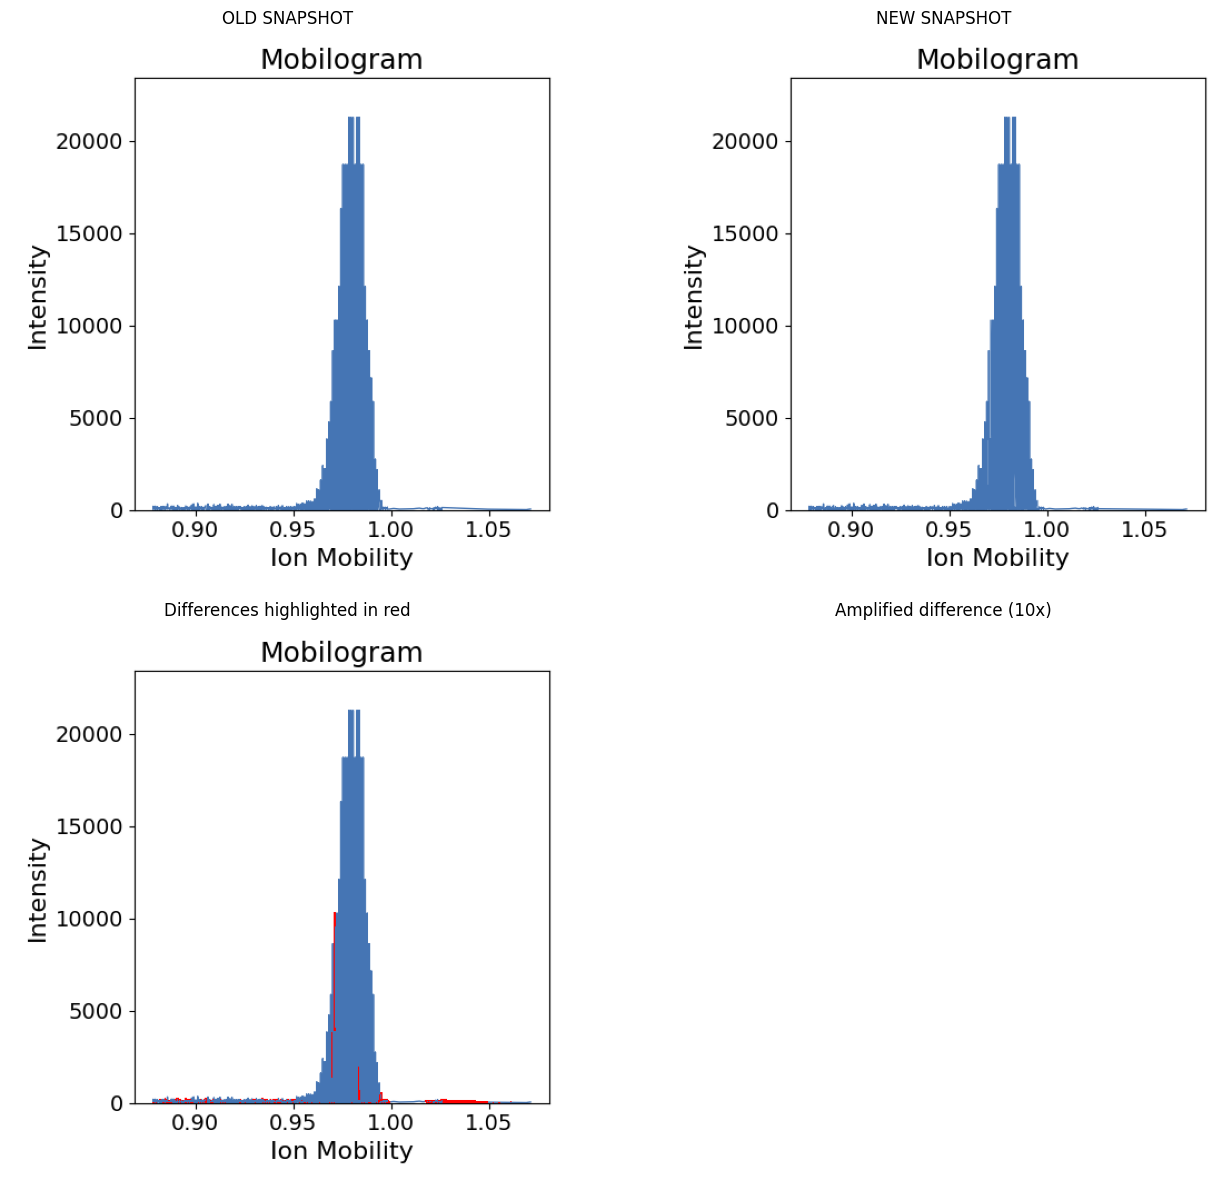

Shape: (500, 500, 4), dtype: uint8
Total differing pixels: 516
Max difference: 186


In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load your images
snap_1 = np.array(Image.open(ORIG_SNAP))
snap_2 = np.array(Image.open(NEW_SNAP))

# Find where they differ
diff_mask = snap_1 != snap_2

# Create a visual diff image (highlight differences in red)
diff_image = snap_1.copy()
if diff_mask.any():
    diff_locations = np.any(diff_mask, axis=-1) if diff_mask.ndim == 3 else diff_mask
    if snap_1.shape[-1] == 4:
        diff_image[diff_locations] = [255, 0, 0, 255]
    else:
        diff_image[diff_locations] = [255, 0, 0]

# Create amplified difference image
abs_diff = np.abs(snap_1.astype(int) - snap_2.astype(int)).astype(np.uint8)
abs_diff_amplified = np.clip(abs_diff * 10, 0, 255).astype(np.uint8)

# Display all images side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(snap_1)
axes[0, 0].set_title("OLD SNAPSHOT")
axes[0, 0].axis("off")

axes[0, 1].imshow(snap_2)
axes[0, 1].set_title("NEW SNAPSHOT")
axes[0, 1].axis("off")

axes[1, 0].imshow(diff_image)
axes[1, 0].set_title("Differences highlighted in red")
axes[1, 0].axis("off")

axes[1, 1].imshow(abs_diff_amplified)
axes[1, 1].set_title("Amplified difference (10x)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# Stats
print(f"Shape: {snap_1.shape}, dtype: {snap_1.dtype}")
print(f"Total differing pixels: {np.sum(np.any(diff_mask, axis=-1) if diff_mask.ndim == 3 else diff_mask)}")
print(f"Max difference: {np.max(np.abs(snap_1.astype(int) - snap_2.astype(int)))}")